# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
for name, df in [('df_hh_income', df_hh_income), ('df_pct_poverty', df_pct_poverty),
                  ('df_pct_completed_hs', df_pct_completed_hs),
                  ('df_share_race_city', df_share_race_city),
                  ('df_fatalities', df_fatalities)]:
    print(f'{name}: {df.shape[0]:,} rows, {df.shape[1]} columns')

df_hh_income: 29,322 rows, 3 columns
df_pct_poverty: 29,329 rows, 3 columns
df_pct_completed_hs: 29,329 rows, 3 columns
df_share_race_city: 29,268 rows, 7 columns
df_fatalities: 2,535 rows, 14 columns


In [6]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [7]:
df_hh_income.head()

,Geographic Area,City,Median Income
0,AL,Abanda CDP,11207
1,AL,Abbeville city,25615
2,AL,Adamsville city,42575
3,AL,Addison town,37083
4,AL,Akron town,21667


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [8]:
# Check for NaN values
print('--- NaN counts ---')
for name, df in [('df_hh_income', df_hh_income), ('df_pct_poverty', df_pct_poverty),
                  ('df_pct_completed_hs', df_pct_completed_hs),
                  ('df_share_race_city', df_share_race_city),
                  ('df_fatalities', df_fatalities)]:
    n = df.isna().sum().sum()
    print(f'{name}: {n} NaN values')

print()
print('--- Duplicate rows ---')
for name, df in [('df_hh_income', df_hh_income), ('df_pct_poverty', df_pct_poverty),
                  ('df_pct_completed_hs', df_pct_completed_hs),
                  ('df_share_race_city', df_share_race_city),
                  ('df_fatalities', df_fatalities)]:
    print(f'{name}: {df.duplicated().sum()} duplicates')

--- NaN counts ---
df_hh_income: 51 NaN values
df_pct_poverty: 0 NaN values
df_pct_completed_hs: 0 NaN values
df_share_race_city: 0 NaN values
df_fatalities: 346 NaN values

--- Duplicate rows ---
df_hh_income: 0 duplicates
df_pct_poverty: 0 duplicates
df_pct_completed_hs: 0 duplicates
df_share_race_city: 0 duplicates
df_fatalities: 0 duplicates


In [9]:
# The census csvs store their numeric columns as text because of placeholder
# values like '-', '(X)', '2,500-' and '250,000+'. Clean each one to a proper
# numeric dtype, treating non-numeric placeholders as missing (0).

def clean_numeric(series):
    s = series.astype(str).str.replace(',', '', regex=False)
    s = s.replace({'-': None, '(X)': None})
    s = s.str.replace('+', '', regex=False).str.replace('-$', '', regex=True)
    return pd.to_numeric(s, errors='coerce')

df_hh_income['Median Income'] = clean_numeric(df_hh_income['Median Income'])
df_pct_poverty['poverty_rate'] = clean_numeric(df_pct_poverty['poverty_rate'])
df_pct_completed_hs['percent_completed_hs'] = clean_numeric(df_pct_completed_hs['percent_completed_hs'])

for col in ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']:
    df_share_race_city[col] = clean_numeric(df_share_race_city[col])

# Substitute remaining NaNs with 0 for the census tables (missing == not reported)
df_hh_income['Median Income'] = df_hh_income['Median Income'].fillna(0)
df_pct_poverty['poverty_rate'] = df_pct_poverty['poverty_rate'].fillna(0)
df_pct_completed_hs['percent_completed_hs'] = df_pct_completed_hs['percent_completed_hs'].fillna(0)
df_share_race_city = df_share_race_city.fillna(0)

print('Cleaned dtypes:')
print(df_hh_income.dtypes)
print(df_pct_poverty.dtypes)
print(df_pct_completed_hs.dtypes)
print(df_share_race_city.dtypes)

Cleaned dtypes:
Geographic Area        str
City                   str
Median Income      float64
dtype: object
Geographic Area        str
City                   str
poverty_rate       float64
dtype: object
Geographic Area             str
City                        str
percent_completed_hs    float64
dtype: object
Geographic area              str
City                         str
share_white              float64
share_black              float64
share_native_american    float64
share_asian              float64
share_hispanic           float64
dtype: object


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [10]:
poverty_by_state = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False)
poverty_by_state.head()

Geographic Area
MS   26.88
AZ   25.27
GA   23.66
AR   22.96
NM   22.51
Name: poverty_rate, dtype: float64

In [11]:
bar = px.bar(
    poverty_by_state,
    x=poverty_by_state.index,
    y=poverty_by_state.values,
    title='Average Poverty Rate by US State (2015)',
    labels={'x': 'State', 'y': 'Poverty Rate (%)'},
    color=poverty_by_state.values,
    color_continuous_scale='Reds',
)
bar.update_layout(xaxis={'categoryorder': 'total descending'}, coloraxis_showscale=False)
bar.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [12]:
hs_by_state = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values()

bar = px.bar(
    hs_by_state,
    x=hs_by_state.index,
    y=hs_by_state.values,
    title='Average High School Graduation Rate by US State (Ascending)',
    labels={'x': 'State', 'y': 'High School Graduation Rate (%)'},
    color=hs_by_state.values,
    color_continuous_scale='Blues',
)
bar.update_layout(xaxis={'categoryorder': 'total ascending'}, coloraxis_showscale=False)
bar.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [13]:
df_stats = pd.merge(poverty_by_state, hs_by_state, left_index=True, right_index=True)
df_stats = df_stats.sort_values('poverty_rate', ascending=False)
df_stats.head()

,poverty_rate,percent_completed_hs
Geographic Area,,
MS,26.88,78.47
AZ,25.27,79.22
GA,23.66,78.63
AR,22.96,79.95
NM,22.51,78.97


/tmp/ipykernel_548/2946397495.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_stats.index, rotation=90)


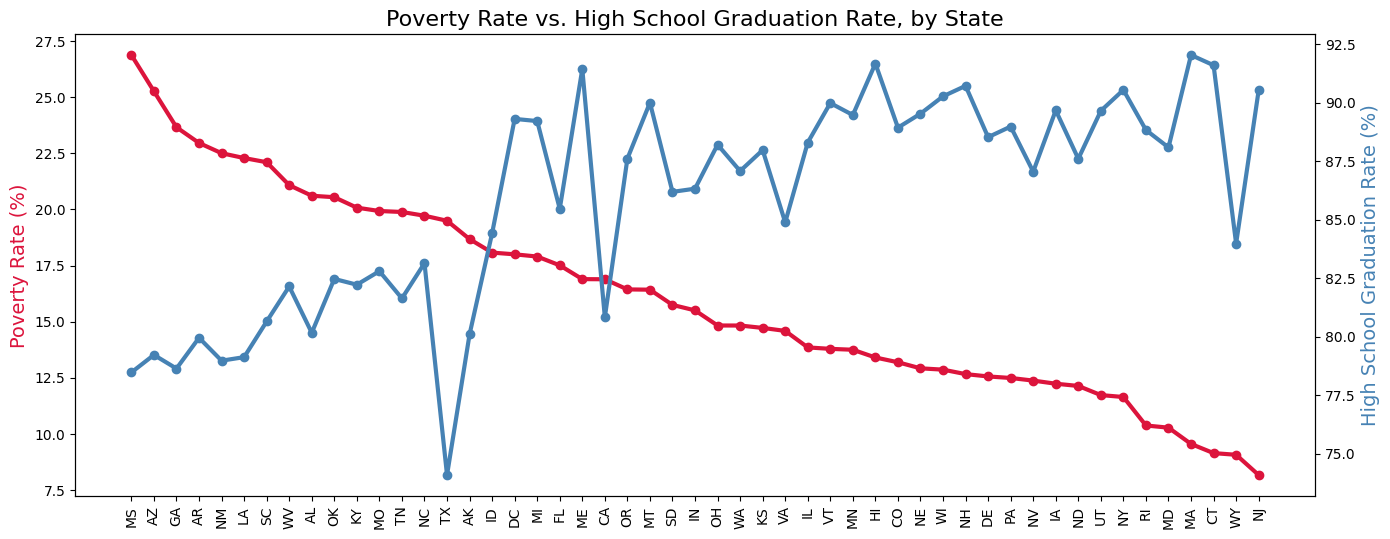

In [14]:
fig, ax1 = plt.subplots(figsize=(16, 6))

ax2 = ax1.twinx()
ax1.set_ylabel('Poverty Rate (%)', color='crimson', fontsize=14)
ax2.set_ylabel('High School Graduation Rate (%)', color='steelblue', fontsize=14)

ax1.plot(df_stats.index, df_stats['poverty_rate'], color='crimson', linewidth=3, marker='o')
ax2.plot(df_stats.index, df_stats['percent_completed_hs'], color='steelblue', linewidth=3, marker='o')

ax1.set_xticklabels(df_stats.index, rotation=90)
plt.title('Poverty Rate vs. High School Graduation Rate, by State', fontsize=16)
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

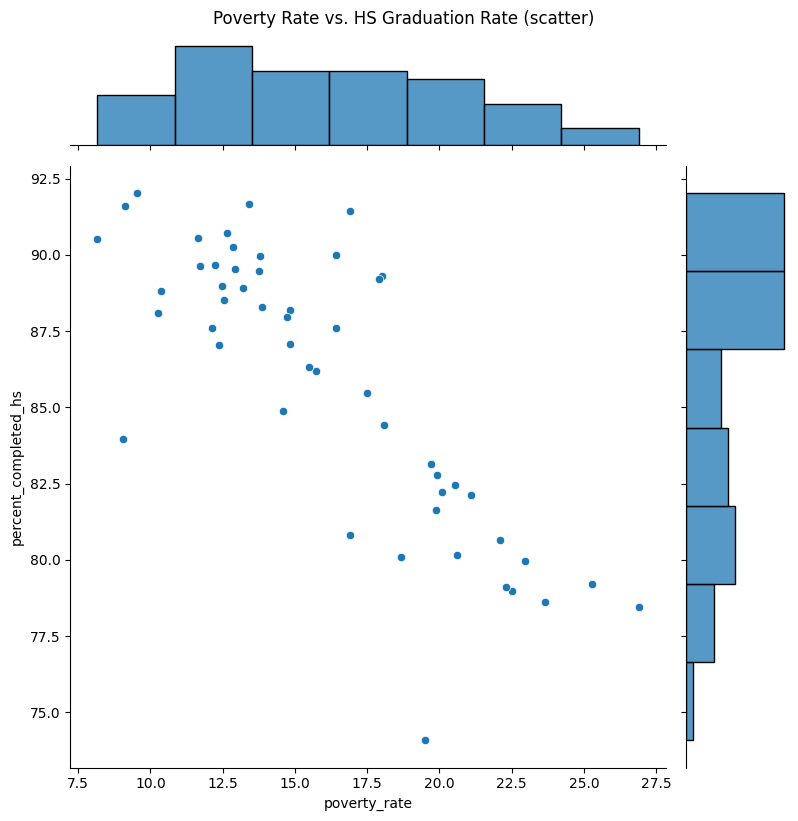

In [15]:
sns.jointplot(
    data=df_stats,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='scatter',
    height=8,
)
plt.suptitle('Poverty Rate vs. HS Graduation Rate (scatter)', y=1.02)
plt.show()

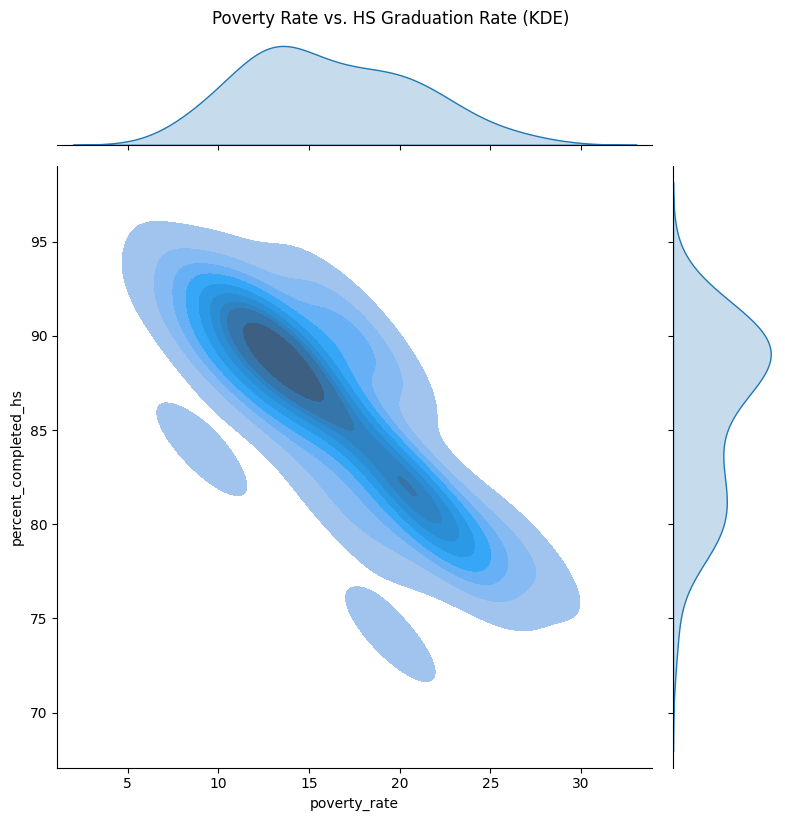

In [16]:
sns.jointplot(
    data=df_stats,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='kde',
    fill=True,
    height=8,
)
plt.suptitle('Poverty Rate vs. HS Graduation Rate (KDE)', y=1.02)
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

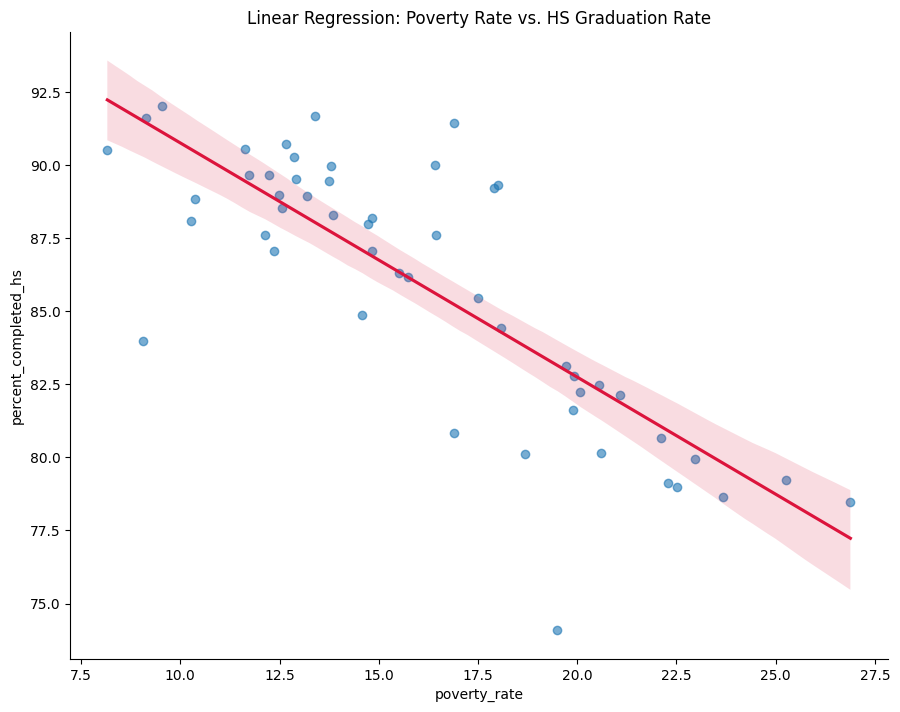

In [17]:
sns.lmplot(
    data=df_stats,
    x='poverty_rate',
    y='percent_completed_hs',
    height=7,
    aspect=1.3,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'crimson'},
)
plt.title('Linear Regression: Poverty Rate vs. HS Graduation Rate')
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [18]:
race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
race_by_state = df_share_race_city.groupby('Geographic area')[race_cols].mean()
race_by_state = race_by_state.sort_values('share_white', ascending=False)
race_by_state.head()

,share_white,share_black,share_native_american,share_asian,share_hispanic
Geographic area,,,,,
IA,96.71,0.56,0.27,0.40,2.82
VT,95.87,0.77,0.37,0.91,1.38
ME,95.69,0.82,0.55,1.03,1.31
NH,95.68,0.72,0.29,1.34,1.74
WV,95.04,2.92,0.20,0.34,0.90


In [19]:
fig = px.bar(
    race_by_state,
    x=race_by_state.index,
    y=race_cols,
    title='Racial Makeup of Each US State (Average Share by City)',
    labels={'value': 'Share of Population (%)', 'x': 'State', 'variable': 'Race'},
)
fig.update_layout(barmode='stack')
fig.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [20]:
race_counts = df_fatalities['race'].value_counts()

race_labels = {
    'W': 'White', 'B': 'Black', 'H': 'Hispanic',
    'A': 'Asian', 'N': 'Native American', 'O': 'Other',
}
race_counts.index = race_counts.index.map(race_labels)
race_counts

race
White              1201
Black               618
Hispanic            423
Asian                39
Native American      31
Other                28
Name: count, dtype: int64

In [21]:
fig = px.pie(
    values=race_counts.values,
    names=race_counts.index,
    title='People Killed by Police, by Race',
    hole=0.4,
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [22]:
gender_counts = df_fatalities['gender'].value_counts()
gender_counts

gender
M    2428
F     107
Name: count, dtype: int64

In [23]:
fig = px.bar(
    x=gender_counts.index.map({'M': 'Male', 'F': 'Female'}),
    y=gender_counts.values,
    title='Total Number of People Killed by Police, by Gender',
    labels={'x': 'Gender', 'y': 'Number of Deaths'},
    color=gender_counts.index,
)
fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

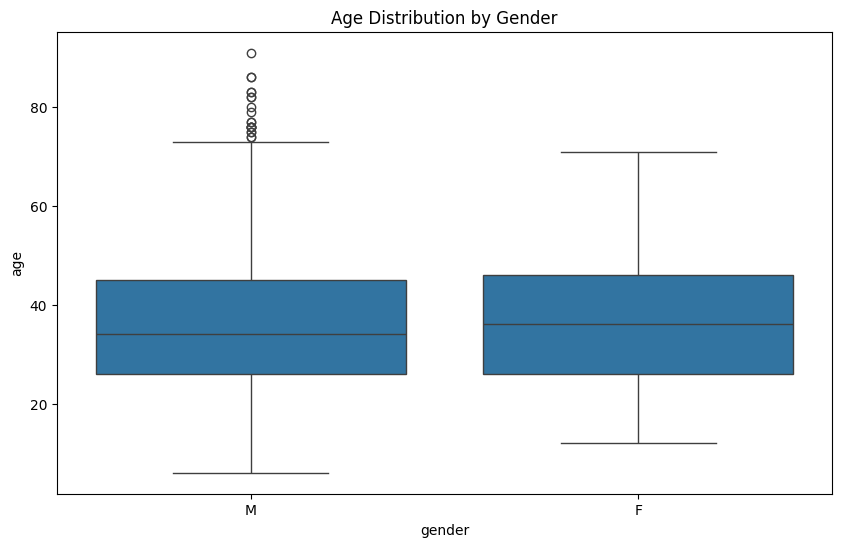

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fatalities, x='gender', y='age')
plt.title('Age Distribution by Gender')
plt.show()

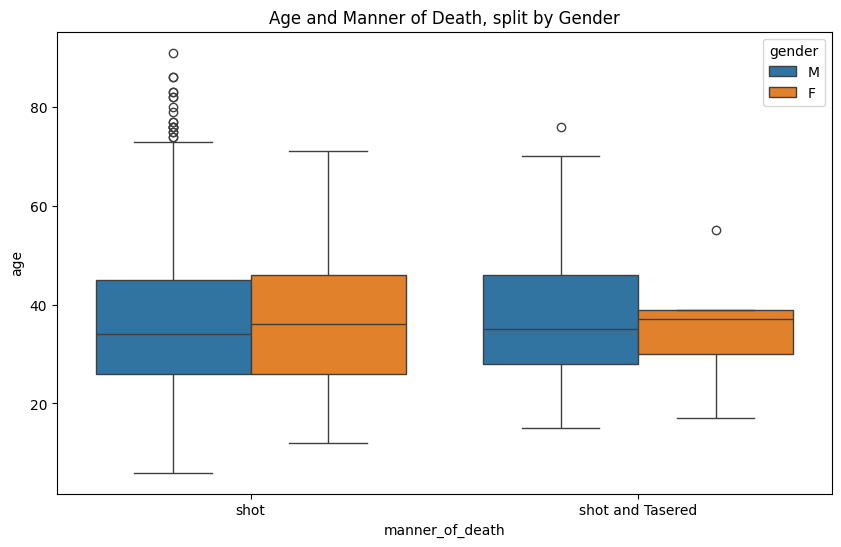

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fatalities, x='manner_of_death', y='age', hue='gender')
plt.title('Age and Manner of Death, split by Gender')
plt.show()

In [26]:
print(df_fatalities.groupby(['gender', 'manner_of_death'])['age'].describe())

                           count  mean   std   min   25%   50%   75%   max
gender manner_of_death                                                    
F      shot                99.00 36.62 12.95 12.00 26.00 36.00 46.00 71.00
       shot and Tasered     5.00 35.60 13.85 17.00 30.00 37.00 39.00 55.00
M      shot             2,191.00 36.57 13.10  6.00 26.00 34.00 45.00 91.00
       shot and Tasered   163.00 37.07 12.21 15.00 28.00 35.00 46.00 76.00


# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [27]:
armed_counts = df_fatalities['armed'].value_counts()
pct_armed = (df_fatalities['armed'] != 'unarmed').mean() * 100
print(f'{pct_armed:.1f}% of people killed were carrying some kind of weapon (armed != "unarmed")')
armed_counts.head(15)

93.3% of people killed were carrying some kind of weapon (armed != "unarmed")


armed
gun               1398
knife              373
vehicle            177
unarmed            171
undetermined       117
toy weapon         104
machete             18
unknown weapon      18
Taser                9
ax                   9
sword                8
baseball bat         8
hammer               7
box cutter           7
metal pipe           7
Name: count, dtype: int64

In [28]:
top_weapons = armed_counts.head(15)
fig = px.bar(
    x=top_weapons.index,
    y=top_weapons.values,
    title='Most Common Weapons Carried by People Killed by Police',
    labels={'x': 'Weapon', 'y': 'Number of Deaths'},
)
fig.show()

In [29]:
gun_vs_unarmed = df_fatalities['armed'].apply(
    lambda x: 'Gun' if x == 'gun' else ('Unarmed' if x == 'unarmed' else 'Other')
).value_counts()

fig = px.pie(
    values=gun_vs_unarmed.values,
    names=gun_vs_unarmed.index,
    title='Gun vs. Unarmed vs. Other Weapon',
    hole=0.4,
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [30]:
pct_under_25 = (df_fatalities['age'] < 25).mean() * 100
print(f'{pct_under_25:.1f}% of the people killed by police were under 25 years old')

17.8% of the people killed by police were under 25 years old


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

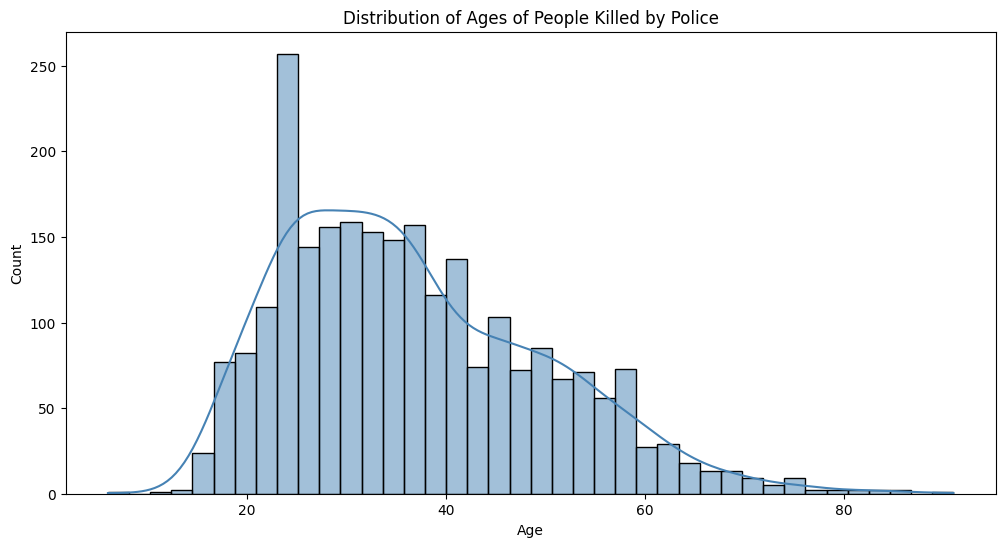

In [31]:
plt.figure(figsize=(12, 6))
sns.histplot(df_fatalities['age'].dropna(), kde=True, bins=40, color='steelblue')
plt.title('Distribution of Ages of People Killed by Police')
plt.xlabel('Age')
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

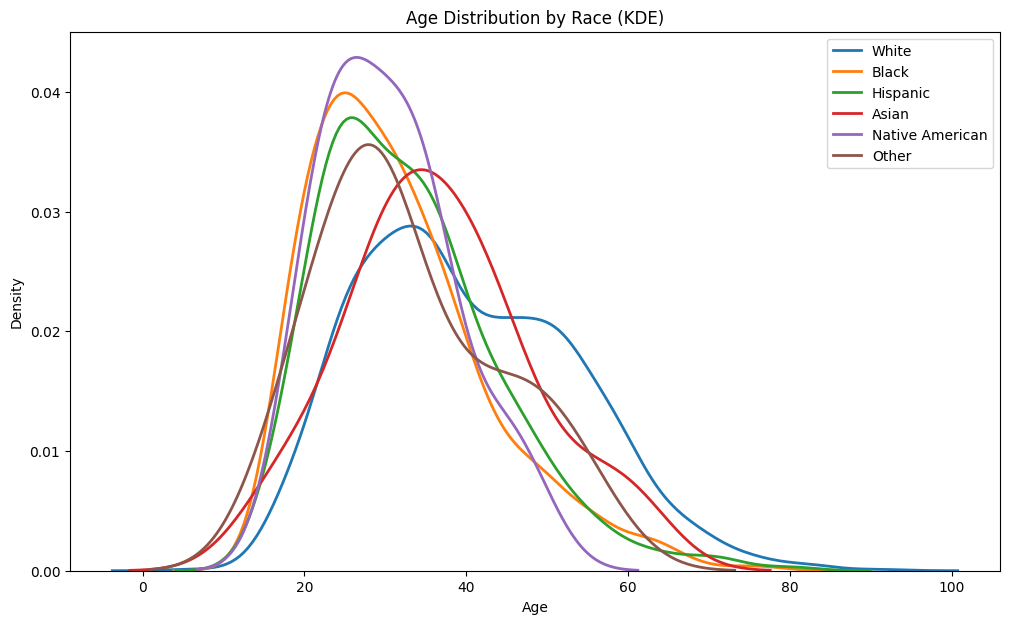

In [32]:
plt.figure(figsize=(12, 7))
for race_code, label in race_labels.items():
    subset = df_fatalities[df_fatalities['race'] == race_code]['age'].dropna()
    if len(subset) > 1:
        sns.kdeplot(subset, label=label, fill=False, linewidth=2)
plt.title('Age Distribution by Race (KDE)')
plt.xlabel('Age')
plt.legend()
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [33]:
fig = px.bar(
    x=race_counts.index,
    y=race_counts.values,
    title='Total Number of People Killed by Police, by Race',
    labels={'x': 'Race', 'y': 'Number of Deaths'},
    color=race_counts.index,
)
fig.show()

In [34]:
race_counts

race
White              1201
Black               618
Hispanic            423
Asian                39
Native American      31
Other                28
Name: count, dtype: int64

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [35]:
pct_mental_illness = df_fatalities['signs_of_mental_illness'].mean() * 100
print(f'{pct_mental_illness:.1f}% of the people killed by police showed signs of mental illness')

25.0% of the people killed by police showed signs of mental illness


In [36]:
mi_counts = df_fatalities['signs_of_mental_illness'].value_counts()
fig = px.pie(
    values=mi_counts.values,
    names=mi_counts.index.map({True: 'Signs of Mental Illness', False: 'No Signs of Mental Illness'}),
    title='Signs of Mental Illness Among People Killed by Police',
    hole=0.4,
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [37]:
top_10_cities = df_fatalities['city'].value_counts().head(10)
top_10_cities

city
Los Angeles    39
Phoenix        31
Houston        27
Chicago        25
Las Vegas      21
San Antonio    20
Columbus       19
Austin         18
Miami          18
St. Louis      15
Name: count, dtype: int64

In [38]:
fig = px.bar(
    x=top_10_cities.index,
    y=top_10_cities.values,
    title='Top 10 Cities with the Most Police Killings (2015-Present)',
    labels={'x': 'City', 'y': 'Number of Deaths'},
    color=top_10_cities.values,
    color_continuous_scale='Reds',
)
fig.update_layout(coloraxis_showscale=False)
fig.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [39]:
top_10_city_names = top_10_cities.index.tolist()

# Share of each race in the top 10 cities (from the census data)
race_share_top10 = df_share_race_city[df_share_race_city['City'].isin(top_10_city_names)]
race_share_top10 = race_share_top10.set_index('City')[race_cols]
race_share_top10

,share_white,share_black,share_native_american,share_asian,share_hispanic
City,,,,,


In [40]:
deaths_by_race_top10 = df_fatalities[df_fatalities['city'].isin(top_10_city_names)].groupby(['city', 'race']).size().unstack(fill_value=0)
deaths_by_race_top10

race,A,B,H,N,O,W
city,,,,,,
Austin,0,3,2,0,0,13
Chicago,0,21,1,0,0,2
Columbus,0,11,0,0,1,6
Houston,1,15,6,1,0,3
Las Vegas,0,3,5,0,0,9
Los Angeles,1,10,19,0,0,6
Miami,0,8,6,0,0,3
Phoenix,0,2,11,3,0,12
San Antonio,0,3,12,0,0,3


# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [41]:
state_deaths = df_fatalities['state'].value_counts().reset_index()
state_deaths.columns = ['state', 'deaths']
state_deaths.head()

,state,deaths
0,CA,424
1,TX,225
2,FL,154
3,AZ,118
4,OH,79


In [42]:
fig = px.choropleth(
    state_deaths,
    locations='state',
    locationmode='USA-states',
    color='deaths',
    scope='usa',
    color_continuous_scale='Reds',
    title='Number of Police Killings by US State (2015-Present)',
)
fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [43]:
df_fatalities['date_parsed'] = pd.to_datetime(df_fatalities['date'], format='%d/%m/%y')
df_fatalities['year_month'] = df_fatalities['date_parsed'].dt.to_period('M').astype(str)
killings_over_time = df_fatalities.groupby('year_month').size()
killings_over_time.head()

year_month
2015-01    76
2015-02    77
2015-03    92
2015-04    84
2015-05    71
dtype: int64

In [44]:
fig = px.line(
    x=killings_over_time.index,
    y=killings_over_time.values,
    title='Number of Police Killings Over Time (Monthly)',
    labels={'x': 'Month', 'y': 'Number of Deaths'},
)
fig.show()

In [45]:
df_fatalities['year'] = df_fatalities['date_parsed'].dt.year
killings_by_year = df_fatalities.groupby('year').size()
fig = px.bar(
    x=killings_by_year.index,
    y=killings_by_year.values,
    title='Number of Police Killings by Year',
    labels={'x': 'Year', 'y': 'Number of Deaths'},
)
fig.show()

In [46]:
# A rolling 3-month average smooths out month-to-month noise and makes any
# longer-term trend easier to see.
rolling = killings_over_time.rolling(3).mean()
fig = px.line(
    x=rolling.index,
    y=rolling.values,
    title='Police Killings Over Time (3-Month Rolling Average)',
    labels={'x': 'Month', 'y': 'Avg. Number of Deaths'},
)
fig.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).